## CLUSTERING with DBSCAN:
- Given the synthetic dataset generated with the snippet below, carry out the following analyses:
    - **Clustering with DBSCAN**. 
        - Try to use DBSCAN algorithm with different parameter configurations. How does it model your distribution of objects?
        - How can you estimate a reasonable value of `eps` parameter?


In [8]:
#courtesy function to plot data
def plot_data(y,title):
    plt.figure(figsize = (5,5))
    plt.scatter(data[:,0],data[:,1], c = y, cmap='Spectral_r')
    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim([-11,11])
    plt.ylim([-11,11])
    plt.show()
#plot_data(target,'original data')

## Data creation

In [9]:
import pandas as pd
import numpy as np
np.random.seed(10)
from sklearn.metrics import classification_report as clfrep
from matplotlib import pyplot as plt

### -> Data creation step 1:
Create five blobs: notice that one is "less dense" than other, due to higher value of imposed standard deviation. 

In [10]:
np.random.seed(10)

Number of synth clusters = 5, labelled as [0 1 2 3 4] -> 5 different colors
cluster_std = [0.1, 0.1, 0.1, 0.1, 1], so 4 out of 5 clusters have same std


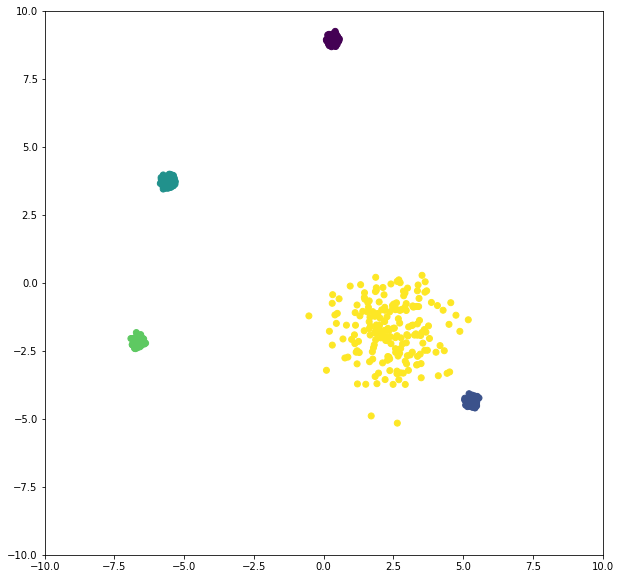

In [11]:
from sklearn.datasets import make_blobs  #make_blobs create gaussian-distributed clusters

cluster_std = [0.1,0.1,0.1,0.1, 1]

X, y = make_blobs(n_samples=1000, 
                  centers=5,
                  cluster_std = cluster_std,   # standard deviation of data in each cluster
                  center_box = (-10,10), #[-10,10],    # The bounding box for each cluster center 
                  n_features=2, 
                  random_state=23)
plt.figure(figsize=(10,10))
plt.scatter([x[0] for x in X],[x[1] for x in X],c = y);
plt.xlim([-10,10]);
plt.ylim([-10,10]);
print(f"Number of synth clusters = {len(np.unique(y))}, labelled as {np.unique(y)} -> {len(np.unique(y))} different colors")
print(f"cluster_std = {cluster_std}, so 4 out of 5 clusters have same std")


### NOTE!!! 
In real-life scenarios, we do not have the ground truth (that is, we do not know  the number of clusters, and if you are an outlier or an inlier).
Here, we will use it to understand the model behaviour.

### Thus: we are NOT DOING CLASSIFICATION!!!

### -> Data creation step 2:
Add outliers to the dataset: outliers are modelled as 20 instances sampled uniformly in the bidimensional space. 

target_anomaly can be = [0 1] , that is 0 for inliers or 1 for outliers


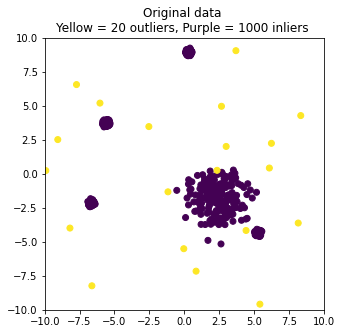

In [12]:
outliers = np.random.uniform(-10,10,(20,2))
data = np.concatenate((X,outliers))
target = np.concatenate((y,np.asarray([-1 for x in range(len(outliers))])))
target_anomaly = np.minimum(target,0)*(-1)  #target_anomaly evaluate the minimum between target and zero -> it will return 0 for inliers, 1 for outliers
print("target_anomaly can be =", np.unique(target_anomaly), ", that is 0 for inliers or 1 for outliers" )

plt.figure(figsize=(5,5))
plt.scatter(data[:,0],data[:,1],c = target_anomaly)  #<-c= (color) 0 if inlier, 1 if outlier
plt.xlim([-10,10])
plt.ylim([-10,10])
plt.title('Original data \nYellow = 20 outliers, Purple = 1000 inliers ')
plt.show()

## QUESTION on synthetic dataset vs real-world data
With respect to real-life scenarios, what are major differences you can see?

``` {1: convex shape (from a gaussian distrib); 2: just bidimensional dataset }
Click to show
```

DBSCAN clustering mainly depends on the combination of the two parameters: $\varepsilon$ and $\mbox{MinPts}$. In the following we fix $\mbox{MinPts}$ and vary $\varepsilon$ in a reasonable range.


To monitor the capability of recognizing outlier, for each clustering evaluation we report:
- the 2D plot with cluster/outlier assignment
- the "classification" report for the assessment of the capability of discriminating outlier/inlier with respect to the ground truth


### NOTE (again)!!! 
In real-life scenarios, we do not have the ground truth (that is, we do not know  the number of clusters, and if you are an outlier or an inlier). Here, we use it to understand the model behaviour.

Thus (AGAIN): today we are NOT DOING CLASSIFICATION!!!

Printing output of db-scan... [ 0  1  2 ... -1 -1 -1]
Number of clusters found = 6

Comments:
In this experiment, with min_samples = 4 and eps = 0.444, we found 6 clusters. 
They are indicated numbers starting from 0, while -1 is used to indicate outliers


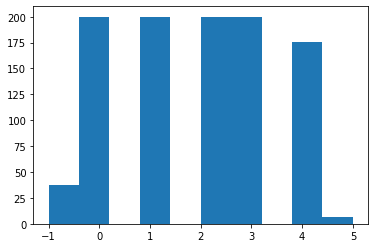

In [32]:
# just one experiment, to understand the outputs of DB-SCAN
from sklearn.cluster import DBSCAN
min_samples = 4
eps=0.444
dbscan = DBSCAN(min_samples = min_samples, eps = eps)  # create model
y_assignment_clusters =dbscan.fit_predict(data); # fit AND predict on the data
print("Printing output of db-scan...", y_assignment_clusters)
print(f"Number of clusters found = {len(set(y_assignment_clusters))-1}\n")
plt.hist(y_assignment_clusters );

print(f"Comments:\nIn this experiment, with min_samples = {min_samples} and eps = {eps}, we found {len(set(y_assignment_clusters))-1} clusters. \nThey are indicated numbers starting from 0, while -1 is used to indicate outliers")

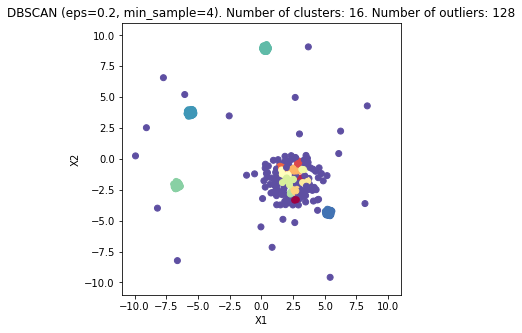

              precision    recall  f1-score   support

      normal       1.00      0.89      0.94      1000
     outlier       0.16      1.00      0.27        20

    accuracy                           0.89      1020
   macro avg       0.58      0.95      0.61      1020
weighted avg       0.98      0.89      0.93      1020

-------------------------------------------------

Comment (if we assume to have ground truth):
Low value of epsilon=0.2 means small radius: -> "fragmentation" of the least dense class -> many small clusters will be identified, "real" cores will not be identified and linked
Thus we are identifiying all actual outliers (and many others as outliers)-> this means high recall = (tp/(tp+fn)-> number of false negatives is minimized
On the other hand, we have small precision=tp/(tp+fp) =0.16 for the outlier (because we have many false positives) 

-------------------------------------------------



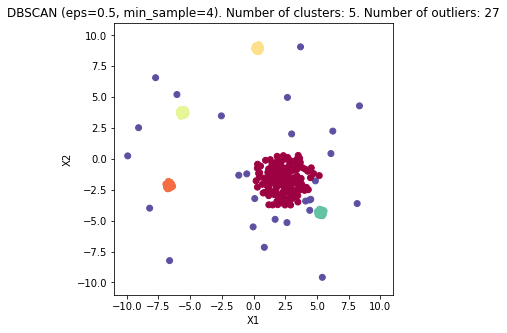

              precision    recall  f1-score   support

      normal       1.00      0.99      1.00      1000
     outlier       0.70      0.95      0.81        20

    accuracy                           0.99      1020
   macro avg       0.85      0.97      0.90      1020
weighted avg       0.99      0.99      0.99      1020

-------------------------------------------------

Comment (if we assume to have ground truth):
Value of epsilon=0.5 seems better, but looking at the confusion matrix we see some mistakes -> we are confusing the tail of the gaussian distributions
-------------------------------------------------



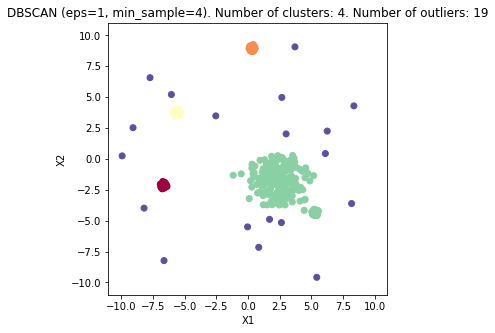

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      1000
     outlier       0.89      0.85      0.87        20

    accuracy                           1.00      1020
   macro avg       0.95      0.92      0.93      1020
weighted avg       0.99      1.00      1.00      1020

-------------------------------------------------

Comment (if we assume to have ground truth):
Value of epsilon=1, ne small cluster is associated to the large one. Some mistakes, looking at the tail
-------------------------------------------------



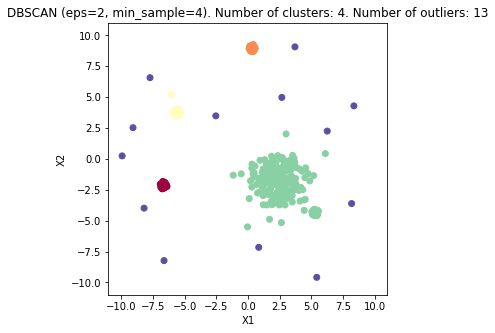

              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      1000
     outlier       1.00      0.65      0.79        20

    accuracy                           0.99      1020
   macro avg       1.00      0.82      0.89      1020
weighted avg       0.99      0.99      0.99      1020

-------------------------------------------------

Comment (if we assume to have ground truth):
Value of epsilon=2, one small cluster is associated to the large one, and many outliers are associated to the large blue cluster
-------------------------------------------------



In [15]:
from sklearn.cluster import DBSCAN

min_samples = 4   #we fix min_points. 
#In general, the result of the DBSCAN is quite robus if we fix min_samples and we find a good value for eps

for eps in [0.2,0.5,1,2]:
    dbscan = DBSCAN(min_samples = min_samples, eps = eps)
    y_assignment = dbscan.fit_predict(data)
    n_cluster = len(np.unique(y_assignment))-1   # instances are assigned to clusters or to outliers, so we subtract 1
    n_outlier = list(y_assignment).count(-1)
    plot_data(y_assignment,f'DBSCAN (eps={eps}, min_sample={min_samples}). Number of clusters: {n_cluster}. Number of outliers: {n_outlier}')
    # remember: DBSCAN: Noisy samples are given the label -1.
    y_assignment_eval = np.minimum(y_assignment,0)*(-1)

    # 0 for all clusters (inlier), 1 for outlier
    
    print(clfrep(target_anomaly,y_assignment_eval,target_names = ['normal','outlier']))
    print("-------------------------------------------------\n")
    print("Comment (if we assume to have ground truth):")
    if eps ==0.2:
        print("Low value of epsilon=0.2 means small radius: -> \"fragmentation\" of the least dense class -> many small clusters will be identified, \"real\" cores will not be identified and linked")
        print("Thus we are identifiying all actual outliers (and many others as outliers)-> this means high recall = (tp/(tp+fn)-> number of false negatives is minimized")
        print("On the other hand, we have small precision=tp/(tp+fp) =0.16 for the outlier (because we have many false positives) \n")
    elif eps==0.5:
        print("Value of epsilon=0.5 seems better, but looking at the confusion matrix we see some mistakes -> we are confusing the tail of the gaussian distributions")
    elif eps==1:
        print("Value of epsilon=1, ne small cluster is associated to the large one. Some mistakes, looking at the tail")
    elif eps==2:
        print("Value of epsilon=2, one small cluster is associated to the large one, and many outliers are associated to the large blue cluster")
        
    print("-------------------------------------------------\n")


### IN SUMMARY:
- with low value of $\varepsilon$ ($\varepsilon=0.2$), DBSCAN fails to model the "most sparse" (biggest) blob: many of its objects are improperly marked as outliers. The recall is high (since all actual outliers are recognized as such) but the precision is very low (0.16).
- increasing the value of $\varepsilon$ (larger neighborhood)
    - precision increases: the number of false positive decreases
    - recall decreases: outliers are incorporated in cluster borders.
    
 

# Evaluate epsilon (given min(points))
 

### STRATEGY 1: assess a-prori epsilon and min(points)
visualize and observe the density of your data (density is related to epsilon and min(points))

In general, you arbitrary set the value of min(points) and then look for epsilon



###  STRATEGY 2: k-dist plot

The $k$-dist plot can be used for estimating a reasonable value of $\varepsilon$ parameter.<br>
_(also called min(points) plot )_

In brief, we evaluate the distance of each instance to its k-nearest neightboor. 



<img src="image/kth_distance_marcelloni.png" width=400 height=400 />



We then try to identity a "theshold point" dividing noise from natural clusters

<img src="image/kdist_plot_Marcelloni.png" width=400 height=400 />

In [16]:
from sklearn.neighbors import NearestNeighbors

minpts = 4 #-> we evaluate the distance of each instance from its 4-th nearest neightboor

nbrs = NearestNeighbors(n_neighbors=minpts).fit(data) 
distances, indices = nbrs.kneighbors(data)
print("distances (4 elements) for each instance \n", distances)
print("if you look at the distances, the first one is 0 -> the distance with itself")
print("This is in agreement with the definition on min(points) (that include the instance itself)")

distances (4 elements) for each instance 
 [[0.         0.01102872 0.01156018 0.01289783]
 [0.         0.01195266 0.01331328 0.01517864]
 [0.         0.00862781 0.01798697 0.02129014]
 ...
 [0.         2.12043531 2.13453588 2.13453949]
 [0.         2.16459704 3.26055063 3.29244784]
 [0.         2.43821066 3.40175371 3.4287242 ]]
if you look at the distances, the first one is 0 -> the distance with itself
This is in agreement with the definition on min(points) (that include the instance itself)


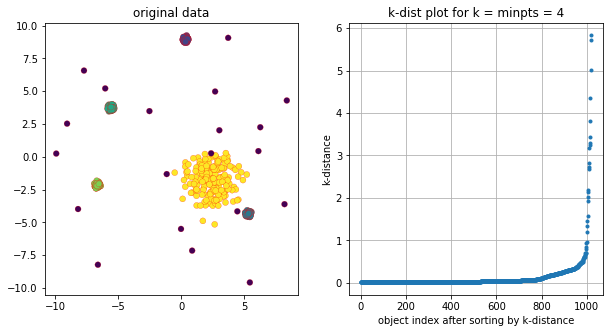

In [11]:
k_dist = [x[-1] for x in distances]   # <- we get the last element (last distance to the neightboor. Here k=4))

f,ax = plt.subplots(1,2,figsize = (10,5))
ax[0].set_title('original data')
ax[0].scatter(data[:,0],data[:,1],c = target,edgecolors='red',linewidths=0.2)
ax[1].set_title('k-dist plot for k = minpts = 4') 
ax[1].plot(sorted(k_dist),'.')  #<- looking at the sorted values, we can have an insight of a good epsilon value
ax[1].set_xlabel('object index after sorting by k-distance')
ax[1].set_ylabel('k-distance')
#ax[1].axhline(0.5,color = 'r',linestyle = '--')
ax[1].grid()

Objects in the left side of the plot (great majority of objects < 800) have a very low k-distance. <br>

Objects in the right side of the graph are those that are at a higher distance from their $k$-th nearest neighbor (huge compared with the others). Outliers have this kind of behaviour (they have a very large distance with their fourth neightboor).

The "elbow" of the plot can be used for setting the value of $\varepsilon$.

All the instances corresponding to points above the red line have a "relative large" 4-distance


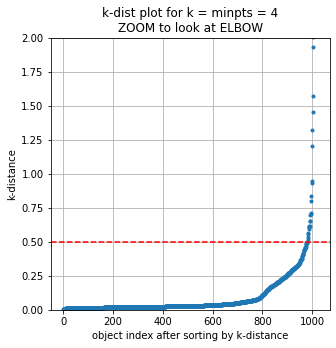

In [12]:
f,ax = plt.subplots(1,1,figsize = (5,5))
ax.set_title('k-dist plot for k = minpts = 4\nZOOM to look at ELBOW') 
ax.plot(sorted(k_dist),'.')
ax.set_xlabel('object index after sorting by k-distance')
ax.set_ylabel('k-distance')
ax.set_ylim([0,2])
ax.axhline(0.5,color = 'r',linestyle = '--')
ax.grid()
print("All the instances corresponding to points above the red line have a \"relative large\" 4-distance")

However, the identification of such an elbow is not always trivial: in our dataset, for example, there is a sharp decrease around index 1000 and a sort of a smaller step around index 800. Objects in between are likely those pertaining to the big, sparse, blob (yellow one). 

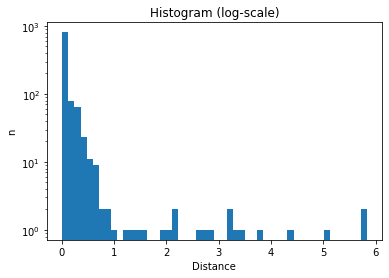

In [13]:
plt.hist(k_dist,bins=50)
plt.xlabel('Distance');
plt.ylabel('n');
plt.yscale('log')
plt.title("Histogram (log-scale)");

# Final remarks

## Comments:
in this way, looking at the k-dist plot, we get to a similar conclusion to the strategy before, but without using "ground truth"

### Pros and Cons of DBSCAN (as clustering technique)


__Pros__:
- DBSCAN is robust to outliers and able to detect the outliers.
- Does not require to know a-priori the number of clusters
- Performs well with arbitrary shapes clusters.

__Cons__:
- you may need domain knowledge to select radius and min points

### -> DBSCAN can also be used to detect ouliers


# IMPORTANT TAKE HOME:
Even when we apply ML models (in this case, with just one parameter), we still have to understand how the models work to give them "good (initial) parameters".

Not black magic, but statistics

Other examples: before fitting the model, you should have a prori idea on the number of k in k-means (you should have an a-priori idea of the number of clusters). We saw that the same is valid for DB-scan (epsilon and minpoints), and so on. 